# Timepix3-style clustering demo

This notebook builds a synthetic `x`, `y`, `time` dataframe with 50,000 input pixels, then uses `clusterer.py` to group pixels into events. The simulated data includes many compact particle-like tracks, one bridge pixel that merges two partial clusters, and isolated noise hits.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from clusterer import cluster_dataframe, cluster_pixels

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Simulate pixel hits

Each row is one hit with integer detector coordinates and a time of arrival in ns. Pixels within one event are spatially 8-connected and have nearby timestamps.

In [8]:
N_PIXELS = 1_000_000
N_TRACKS = 250_000
TRACK_PIXELS = 45
DETECTOR_SIZE = 256
TIME_SPACING_NS = 5_000


def add_track(rows, event_name, start_xy, steps, start_time_ns, dt_ns=35, jitter_ns=8):
    x, y = start_xy
    for step, (dx, dy) in enumerate(steps):
        x += dx
        y += dy
        rows.append({
            "x": int(np.clip(x, 0, DETECTOR_SIZE - 1)),
            "y": int(np.clip(y, 0, DETECTOR_SIZE - 1)),
            "time": float(start_time_ns + step * dt_ns + rng.normal(0, jitter_ns)),
            "truth": event_name,
        })


def random_walk_steps(n_steps):
    choices = np.array([
        [-1, -1], [-1, 0], [-1, 1],
        [0, -1], [0, 1],
        [1, -1], [1, 0], [1, 1],
    ])
    return [tuple(step) for step in choices[rng.integers(0, len(choices), size=n_steps)]]


rows = []

# Many compact tracks. Each one is spatially connected and lasts less than 2000 ns.
for track_id in range(N_TRACKS):
    start_xy = tuple(rng.integers(20, DETECTOR_SIZE - 20, size=2))
    start_time_ns = 10_000 + track_id * TIME_SPACING_NS
    add_track(
        rows,
        f"track_{track_id:04d}",
        start_xy,
        [(0, 0), *random_walk_steps(TRACK_PIXELS - 1)],
        start_time_ns,
    )

# Two partial clusters that become one event when the middle pixel arrives.
bridge_time_ns = 10_000 + (N_TRACKS + 4) * TIME_SPACING_NS
add_track(rows, "bridge_event", (130, 30), [(0, 0), (1, 0)], bridge_time_ns)
add_track(rows, "bridge_event", (133, 30), [(0, 0), (1, 0)], bridge_time_ns + 60)
rows.append({"x": 132, "y": 30, "time": bridge_time_ns + 120.0, "truth": "bridge_event"})

# Isolated noise-like hits. These usually become single-pixel events.
n_noise = N_PIXELS - len(rows)
for i in range(n_noise):
    rows.append({
        "x": int(rng.integers(0, DETECTOR_SIZE)),
        "y": int(rng.integers(0, DETECTOR_SIZE)),
        "time": float(rng.uniform(5_000, bridge_time_ns + 20_000)),
        "truth": "noise",
    })

df = pd.DataFrame(rows).sample(frac=1, random_state=3).reset_index(drop=True)
# assert len(df) == N_PIXELS
df.head(10)

,x,y,time,truth
0,204,208,6.945811e+08,track_138914
1,46,163,9.965307e+08,track_199304
2,227,77,1.576610e+08,track_31530
3,144,131,2.258901e+08,track_45176
4,223,141,5.524414e+08,track_110486
5,222,114,6.783360e+08,track_135665
6,95,202,3.108408e+08,track_62166
7,178,164,2.884203e+08,track_57682
8,32,220,5.427262e+08,track_108543
9,31,41,1.026556e+09,track_205309


## Cluster the pixels

The default `time_window_ns=2000` follows the conservative value used in the paper. Offline data is sorted by time before clustering.

In [3]:
started = perf_counter()
clustered, events = cluster_dataframe(
    df,
    x_col="x",
    y_col="y",
    time_col="time",
    time_window_ns=2_000,
)
elapsed_s = perf_counter() - started

print(f"input pixels: {len(clustered)}")
print(f"clustered events: {len(events)}")
print(f"elapsed: {elapsed_s:.2f} s")

event_summary = pd.DataFrame({
    "cluster_id": [event.id for event in events],
    "n_pixels": [event.size for event in events],
    "min_time_ns": [event.min_time_ns for event in events],
    "max_time_ns": [event.max_time_ns for event in events],
    "duration_ns": [event.duration_ns for event in events],
})

event_summary.describe()

input pixels: 1000000
clustered events: 119905
elapsed: 18.28 s


,cluster_id,n_pixels,min_time_ns,max_time_ns,duration_ns
count,119905.000000,119905.000000,1.199050e+05,1.199050e+05,119905.000000
mean,59952.000000,8.339936,5.000073e+07,5.000098e+07,257.321925
std,34613.736351,16.400514,2.890165e+07,2.890165e+07,574.685251
min,0.000000,1.000000,6.316004e+03,6.316004e+03,0.000000
25%,29976.000000,1.000000,2.491536e+07,2.491653e+07,0.000000
50%,59952.000000,1.000000,5.000002e+07,5.000022e+07,0.000000
75%,89928.000000,1.000000,7.499398e+07,7.499398e+07,0.000000
max,119904.000000,46.000000,1.000500e+08,1.000500e+08,1998.150179


In [4]:
event_summary.sort_values("n_pixels", ascending=False).head(20)

,cluster_id,n_pixels,min_time_ns,max_time_ns,duration_ns
92233,92233,46,7.696001e+07,7.696154e+07,1530.984202
41055,41055,46,3.427501e+07,3.427654e+07,1536.059921
47059,47059,46,3.927000e+07,3.927163e+07,1632.220930
101768,101768,46,8.497000e+07,8.497153e+07,1524.893953
72850,72850,46,6.080000e+07,6.080154e+07,1539.471947
64206,64206,46,5.350989e+07,5.351154e+07,1646.945789
92487,92487,46,7.718499e+07,7.718655e+07,1564.926170
8317,8317,46,6.965004e+06,6.966553e+06,1548.597936
15936,15936,46,1.322967e+07,1.323155e+07,1874.887115
90706,90706,46,7.564002e+07,7.564156e+07,1536.680824


## Visualize the reconstructed events

This plots all 50,000 pixels. Labels are added only for the largest reconstructed events so the plot remains readable.

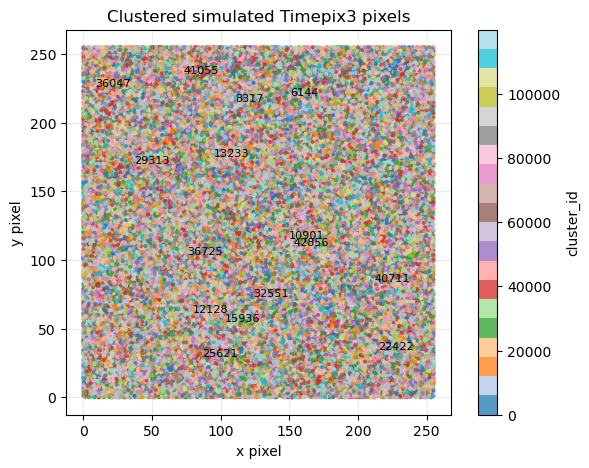

In [5]:
fig, ax = plt.subplots()
scatter = ax.scatter(
    clustered["x"],
    clustered["y"],
    c=clustered["cluster_id"],
    cmap="tab20",
    s=8,
    alpha=0.75,
    linewidth=0,
)

largest_events = sorted(events, key=lambda event: event.size, reverse=True)[:15]
for event in largest_events:
    xs = [pixel["x"] for pixel in event.pixels]
    ys = [pixel["y"] for pixel in event.pixels]
    ax.text(np.mean(xs), np.mean(ys) + 2.0, str(event.id), ha="center", fontsize=8)

ax.set_title("Clustered simulated Timepix3 pixels")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
ax.set_aspect("equal", adjustable="box")
plt.colorbar(scatter, ax=ax, label="cluster_id")
plt.show()

## Check against the simulation labels

The `truth` column is only for this synthetic example. It makes it easy to see which generated hits landed in each reconstructed cluster.

In [6]:
truth_check = (
    clustered
    .groupby("cluster_id")
    .agg(
        n_pixels=("x", "size"),
        truth_labels=("truth", lambda values: ", ".join(sorted(set(values)))),
        time_span_ns=("time", lambda values: values.max() - values.min()),
    )
    .reset_index()
)

truth_check.sort_values("n_pixels", ascending=False).head(25)

,cluster_id,n_pixels,truth_labels,time_span_ns
92233,92233,46,"noise, track_15390",1530.984202
41055,41055,46,"noise, track_6853",1536.059921
47059,47059,46,"noise, track_7852",1632.220930
101768,101768,46,"noise, track_16992",1524.893953
72850,72850,46,"noise, track_12158",1539.471947
64206,64206,46,"noise, track_10700",1646.945789
92487,92487,46,"noise, track_15435",1564.926170
8317,8317,46,"noise, track_1391",1548.597936
15936,15936,46,"noise, track_2644",1874.887115
90706,90706,46,"noise, track_15126",1536.680824


## Try a stricter time window

A smaller window can split tracks whose pixels are spatially connected but spread too far in time.

In [7]:
strict_clustered, strict_events = cluster_dataframe(
    df,
    time_window_ns=120,
)

pd.DataFrame({
    "setting": ["default 2000 ns", "strict 120 ns"],
    "events": [len(events), len(strict_events)],
    "multi_pixel_events": [
        sum(event.size > 1 for event in events),
        sum(event.size > 1 for event in strict_events),
    ],
})

,setting,events,multi_pixel_events
0,default 2000 ns,119905,20052
1,strict 120 ns,336091,228027
